In [1]:
library(dplyr)
library(readr)
library(ggplot2)


Attachement du package : ‘dplyr’


Les objets suivants sont masqués depuis ‘package:stats’:

    filter, lag


Les objets suivants sont masqués depuis ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
energy <- "natural_gas"
hourlyPath  <- paste0("../../curated/", energy, "/gold_hourly_",     energy, ".csv")

In [3]:
# Hourly
energyHourly    <- read_csv(hourlyPath, show_col_types = FALSE)
weatherHourly   <- read_csv("../../curated/weather/gold_hourly_weather.csv", show_col_types = FALSE)

dfHourly <- weatherHourly %>%
    inner_join(energyHourly,   by = c("year", "month", "day", "date", "hour"), suffix = c("", "_energy")) %>%
    select(
        year, 
        month,
        day,
        date,
        hour,
        avg_temp,
        avg_dewpt_temp,
        avg_rel_hum_pct,
        avg_wind_dir,
        avg_wind_spd,
        avg_visib,
        avg_stn_press,
        avg_hmdx,
        avg_wind_chill,
        consumption
    )

# glimpse(dfHourly)
head(dfHourly, 5)

year,month,day,date,hour,avg_temp,avg_dewpt_temp,avg_rel_hum_pct,avg_wind_dir,avg_wind_spd,avg_visib,avg_stn_press,avg_hmdx,avg_wind_chill,consumption
<dbl>,<dbl>,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2012,4,1,2012-04-01,15,10.5,0.2,49,24,7,32.2,101.56,26,-5,0
2012,4,1,2012-04-01,16,9.5,2.1,60,22,19,32.2,101.59,26,-5,0
2012,4,1,2012-04-01,17,8.7,2.4,65,19,26,32.2,101.69,26,-5,0
2012,4,1,2012-04-01,18,8.5,0.9,59,18,15,32.2,101.77,26,-5,0
2012,4,1,2012-04-01,19,8.4,1.6,62,15,13,32.2,101.82,26,-5,25


In [4]:
df <- dfHourly %>%
    filter(year == 2012, month == 4, day < 15) %>%
    mutate(
        time        = format(strptime(hour, format="%H"), format = "%H:00"),
        date_time   = paste0(date, " ", time),
        unix_ts     = as.numeric(as.POSIXct(date_time)),
        instant     = (unix_ts - min(unix_ts)) / (24 * 3600)
    )

head(df, 5)

year,month,day,date,hour,avg_temp,avg_dewpt_temp,avg_rel_hum_pct,avg_wind_dir,avg_wind_spd,avg_visib,avg_stn_press,avg_hmdx,avg_wind_chill,consumption,time,date_time,unix_ts,instant
<dbl>,<dbl>,<dbl>,<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
2012,4,1,2012-04-01,15,10.5,0.2,49,24,7,32.2,101.56,26,-5,0,15:00,2012-04-01 15:00,1333306800,0.00000000
2012,4,1,2012-04-01,16,9.5,2.1,60,22,19,32.2,101.59,26,-5,0,16:00,2012-04-01 16:00,1333310400,0.04166667
2012,4,1,2012-04-01,17,8.7,2.4,65,19,26,32.2,101.69,26,-5,0,17:00,2012-04-01 17:00,1333314000,0.08333333
2012,4,1,2012-04-01,18,8.5,0.9,59,18,15,32.2,101.77,26,-5,0,18:00,2012-04-01 18:00,1333317600,0.12500000
2012,4,1,2012-04-01,19,8.4,1.6,62,15,13,32.2,101.82,26,-5,25,19:00,2012-04-01 19:00,1333321200,0.16666667


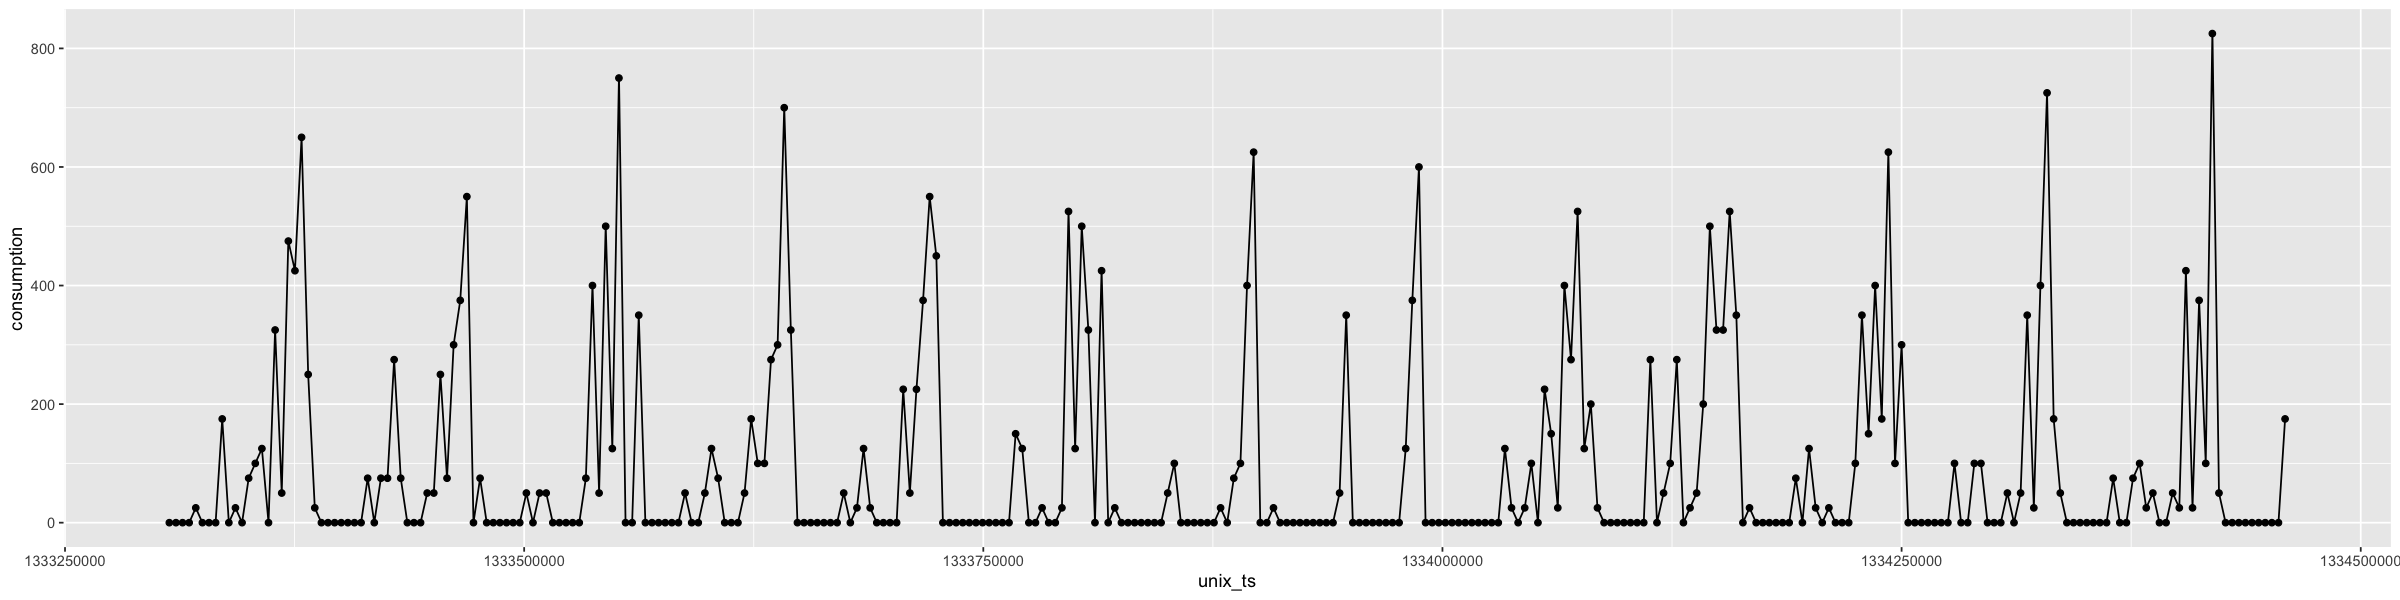

In [5]:
options(repr.plot.width = 20, repr.plot.height = 5)
ggplot(df, aes(x = unix_ts, y = consumption)) +
    geom_point() +
    geom_line()

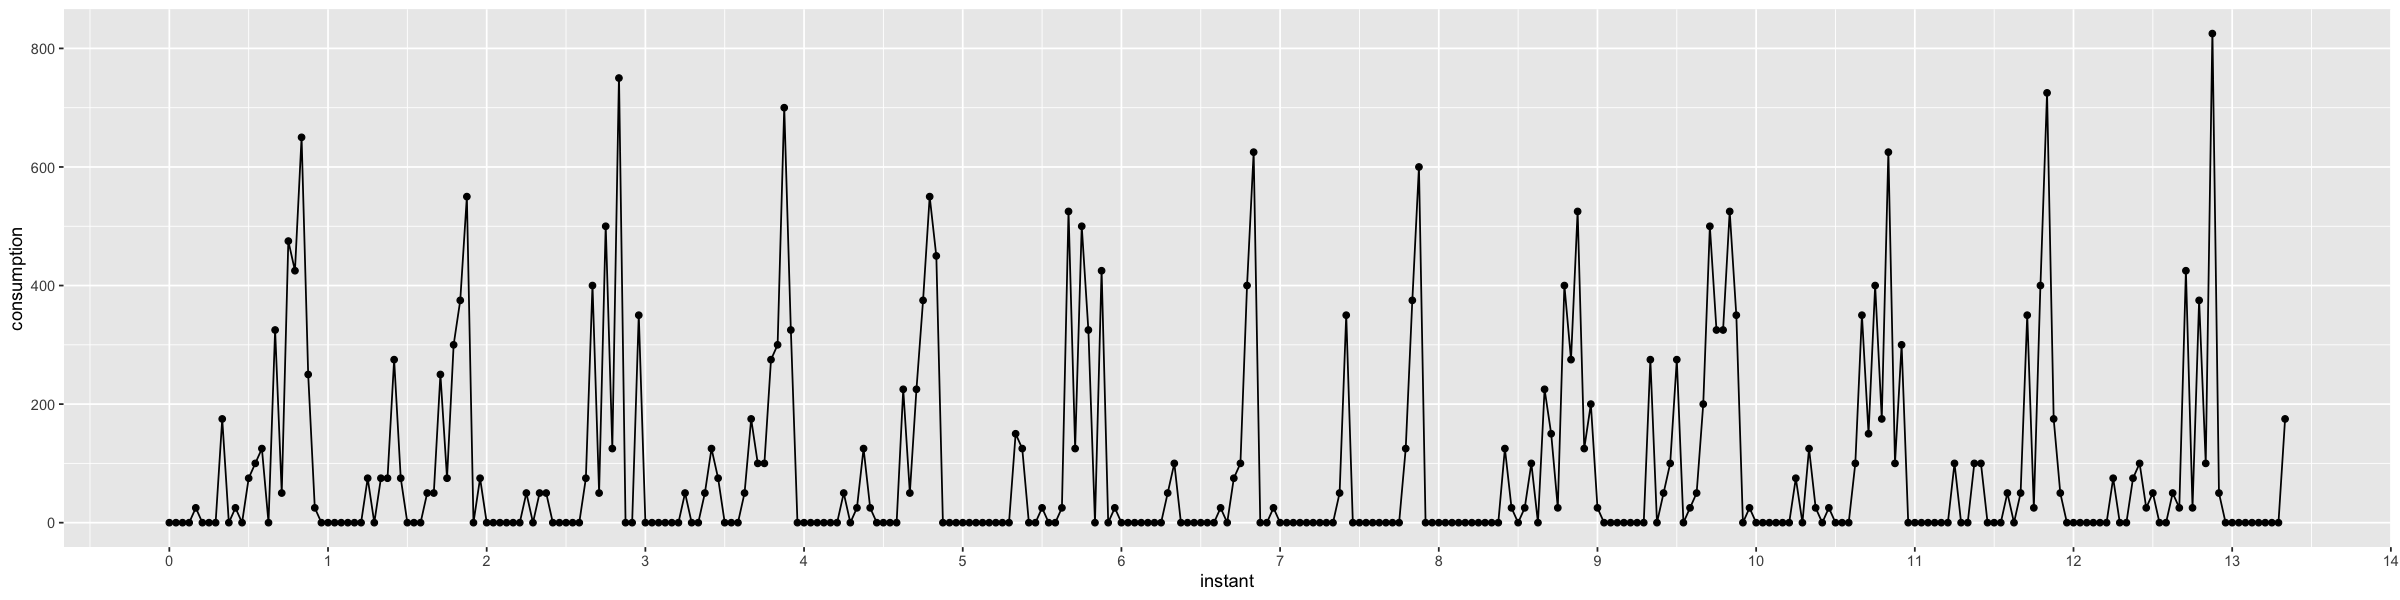

In [6]:
options(repr.plot.width = 20, repr.plot.height = 5)
ggplot(df, aes(x = instant, y = consumption)) +
    geom_point() +
    geom_line() +
    scale_x_continuous(
        breaks = 0:14,
        labels = 0:14
    )

In [7]:
library(ranger)
fmla = "consumption ~ hour"
model_rf <- ranger(as.formula(fmla), dfHourly, num.trees = 500, respect.unordered.factors = "order")
model_lin <- lm(formula=as.formula(fmla), data=dfHourly)
# model_p <- glm(formula=as.formula(fmla), data=dfHourly)

In [12]:
model_p


Call:  glm(formula = as.formula(fmla), data = dfHourly)

Coefficients:
(Intercept)         hour  
   142.7171      -0.1592  

Degrees of Freedom: 17502 Total (i.e. Null);  17501 Residual
Null Deviance:	    751200000 
Residual Deviance: 751200000 	AIC: 236400

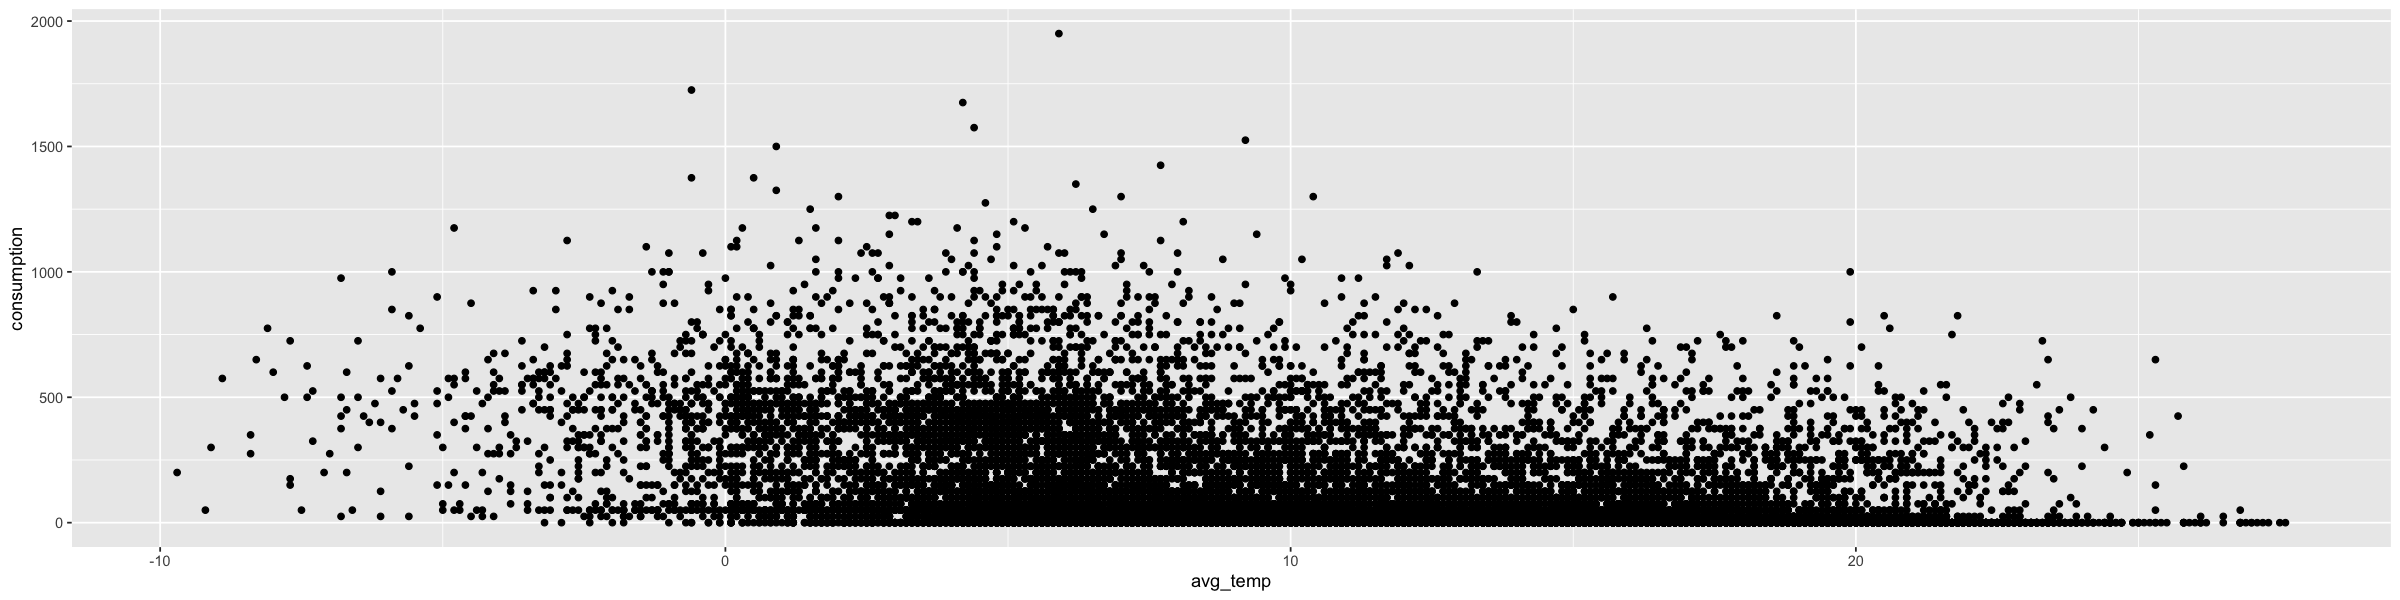

In [15]:
ggplot(dfHourly, aes(x = avg_temp, y = consumption)) +
    geom_point()